# Dataset Exploration
This notebook explores the class balance and structure of the image splits in `data`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random

In [2]:
import os
import torch

print("=== RESOURCE CHECK ===")
# 1. Check CPUs assigned to YOUR specific job (not the whole machine)
print(f"CPUs (Cores) Assigned: {len(os.sched_getaffinity(0))}")

# 2. Check GPUs
gpu_count = torch.cuda.device_count()
print(f"GPUs Available: {gpu_count}")

if gpu_count > 0:
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print("\n=== DETAILED GPU STATUS ===")
    # Runs the system command to show memory usage
    !nvidia-smi
else:
    print("WARNING: No GPU detected. Code will run slow on CPU.")

=== RESOURCE CHECK ===
CPUs (Cores) Assigned: 8
GPUs Available: 0


In [3]:
import torch
print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.9.1+cu128


In [4]:
dataset_root = Path("../data/Dataset")
splits = ["Train", "Validation", "Test"]
split_paths = {split: dataset_root / split for split in splits}
split_paths

{'Train': PosixPath('../data/Dataset/Train'),
 'Validation': PosixPath('../data/Dataset/Validation'),
 'Test': PosixPath('../data/Dataset/Test')}

In [20]:
def collect_split_stats(split_dir: Path) -> pd.DataFrame:
    """Summarise image counts per class for a given split."""
    if not split_dir.exists():
        raise FileNotFoundError(split_dir)
    counts = []
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        image_paths = list(class_dir.glob("**/*"))
        image_paths = [p for p in image_paths if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
        counts.append({"class": class_dir.name, "images": len(image_paths)})
    return pd.DataFrame(counts)
stats_frames = {split: collect_split_stats(path) for split, path in split_paths.items()}
stats_frames

{'Train':   class  images
 0  Fake   69841
 1  Real   70001,
 'Validation':   class  images
 0  Fake   19641
 1  Real   19787,
 'Test':   class  images
 0  Fake    5492
 1  Real    5413}

In [21]:
summary_rows = []
for split, df in stats_frames.items():
    total = int(df["images"].sum()) if not df.empty else 0
    for _, row in df.iterrows():
        summary_rows.append({"split": split, "class": row["class"], "images": int(row["images"]), "proportion_within_split": row["images"] / total if total else 0.0})
summary_df = pd.DataFrame(summary_rows).sort_values(["split", "class"])
summary_df

,split,class,images,proportion_within_split
4,Test,Fake,5492,0.503622
5,Test,Real,5413,0.496378
0,Train,Fake,69841,0.499428
1,Train,Real,70001,0.500572
2,Validation,Fake,19641,0.498149
3,Validation,Real,19787,0.501851


/tmp/ipykernel_46259/3530414415.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["class"], rotation=45, ha="right")
/tmp/ipykernel_46259/3530414415.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["class"], rotation=45, ha="right")
/tmp/ipykernel_46259/3530414415.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["class"], rotation=45, ha="right")


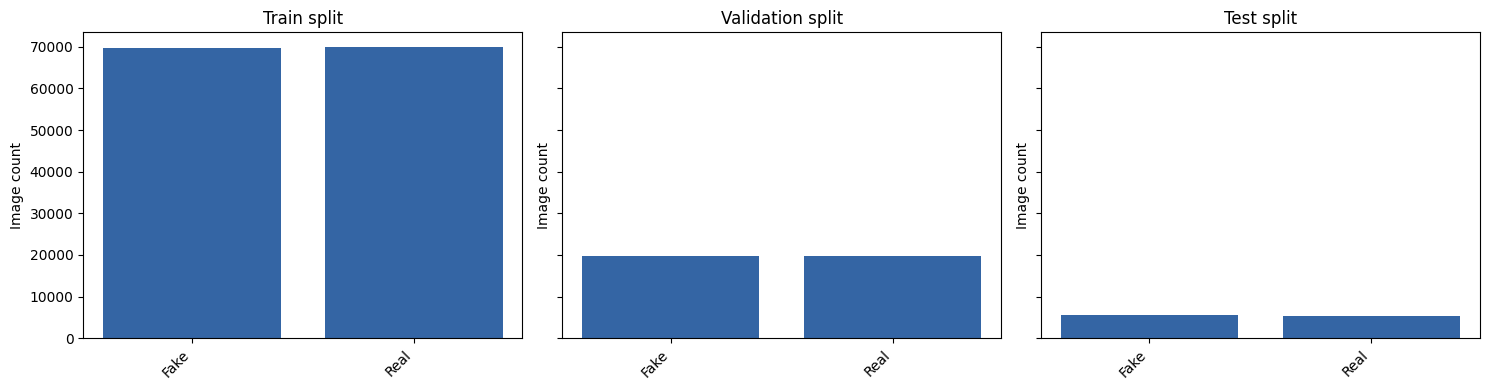

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=len(splits), figsize=(5 * len(splits), 4), sharey=True)
if len(splits) == 1:
    axes = [axes]
for ax, split in zip(axes, splits):
    df = summary_df[summary_df["split"] == split]
    ax.bar(df["class"], df["images"], color="#3465a4")
    ax.set_title(f"{split} split")
    ax.set_ylabel("Image count")
    ax.set_xticklabels(df["class"], rotation=45, ha="right")
plt.tight_layout()

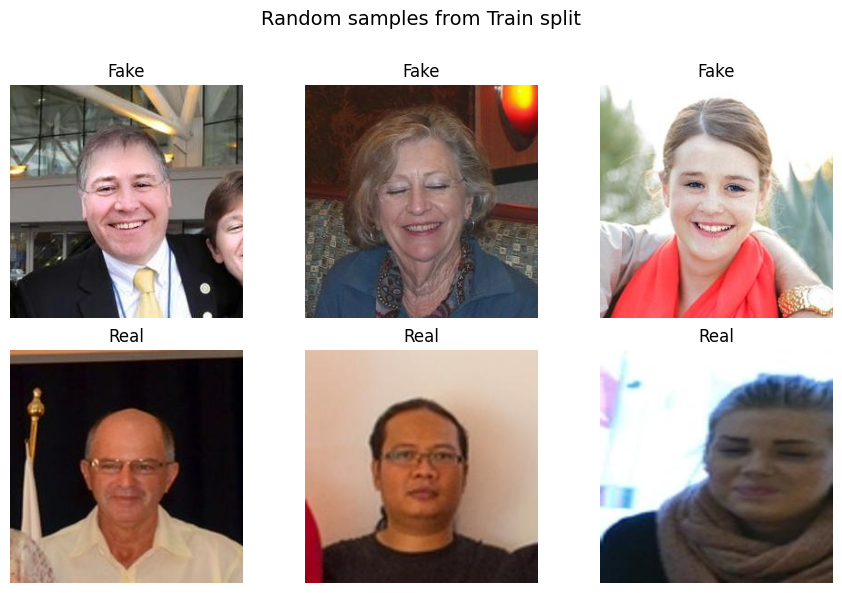

In [23]:
def show_random_samples(split: str, samples_per_class: int = 3):
    split_dir = split_paths[split]
    class_dirs = [p for p in split_dir.iterdir() if p.is_dir()]
    n_cols = samples_per_class
    n_rows = len(class_dirs)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_idx, class_dir in enumerate(sorted(class_dirs, key=lambda p: p.name)):
        images = [p for p in class_dir.glob("**/*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
        if not images:
            continue
        # Use random.sample instead of np.random.choice for Path objects
        chosen = random.sample(images, k=min(samples_per_class, len(images)))
        for col_idx, image_path in enumerate(chosen):
            ax = axes[row_idx, col_idx] if n_rows > 1 else axes[col_idx]
            with Image.open(image_path) as img:
                ax.imshow(img)
            ax.set_title(f"{class_dir.name}")
            ax.axis("off")
    fig.suptitle(f"Random samples from {split} split", fontsize=14)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
show_random_samples("Train")

## Follow-up Checks
- Verify class directories contain only image files; clean anomalies before training.\n- Inspect additional samples for artifacts (compression, resolution) that could bias the model.\n- Consider computing per-class mean/variance or image resolution stats for preprocessing guidance.

## Image Resolution & Aspect Ratios
Analyze the distribution of image dimensions to guide resizing strategies.

In [24]:
from typing import Optional
def gather_image_metadata(split_dir: Path, max_images_per_class: Optional[int] = None) -> pd.DataFrame:
    records = []
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        image_paths = [p for p in class_dir.glob("**/*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
        if max_images_per_class is not None and len(image_paths) > max_images_per_class:
            # Use random.sample instead of np.random.choice for Path objects
            image_paths = random.sample(image_paths, k=max_images_per_class)
        for path in image_paths:
            try:
                with Image.open(path) as img:
                    width, height = img.size
                    mode = img.mode
            except (OSError, ValueError):
                continue
            records.append({
                "class": class_dir.name,
                "path": str(path),
                "width": width,
                "height": height,
                "aspect_ratio": width / height if height else np.nan,
                "mode": mode
            })
    return pd.DataFrame(records)
train_metadata = gather_image_metadata(split_paths["Train"], max_images_per_class=None)
train_metadata.head()

,class,path,width,height,aspect_ratio,mode
0,Fake,../data/Dataset/Train/Fake/fake_64465.jpg,256,256,1.0,RGB
1,Fake,../data/Dataset/Train/Fake/fake_42823.jpg,256,256,1.0,RGB
2,Fake,../data/Dataset/Train/Fake/fake_32359.jpg,256,256,1.0,RGB
3,Fake,../data/Dataset/Train/Fake/fake_37876.jpg,256,256,1.0,RGB
4,Fake,../data/Dataset/Train/Fake/fake_37904.jpg,256,256,1.0,RGB


In [25]:
resolution_summary = (
    train_metadata.groupby("class")[['width', 'height']]
    .agg(['mean', 'median', 'min', 'max'])
    .round(1)
)
resolution_summary

width                  height                 
        mean median  min  max   mean median  min  max
class                                                
Fake   256.0  256.0  256  256  256.0  256.0  256  256
Real   256.0  256.0  256  256  256.0  256.0  256  256

## Color Intensity Profiles
Compute per-channel intensity statistics for a subset of training images to spot distribution shifts.

In [26]:
def sample_color_statistics(metadata: pd.DataFrame, sample_size: int = 200) -> pd.DataFrame:
    if metadata.empty:
        return pd.DataFrame()
    sample_df = metadata.sample(n=min(sample_size, len(metadata)), random_state=42)
    channel_stats = []
    for _, row in sample_df.iterrows():
        path = Path(row['path'])
        try:
            with Image.open(path) as img:
                img = img.convert('RGB')
                arr = np.asarray(img, dtype=np.float32) / 255.0
        except (OSError, ValueError):
            continue
        for idx, channel in enumerate(['R', 'G', 'B']):
            channel_values = arr[..., idx].reshape(-1)
            channel_stats.append({
                'class': row['class'],
                'channel': channel,
                'mean': float(channel_values.mean()),
                'std': float(channel_values.std()),
                'path': row['path']
            })
    return pd.DataFrame(channel_stats)
color_stats = sample_color_statistics(train_metadata)
color_stats.head()

,class,channel,mean,std,path
0,Fake,R,0.596018,0.222938,../data/Dataset/Train/Fake/fake_53624.jpg
1,Fake,G,0.552913,0.262665,../data/Dataset/Train/Fake/fake_53624.jpg
2,Fake,B,0.517376,0.272752,../data/Dataset/Train/Fake/fake_53624.jpg
3,Real,R,0.328285,0.262281,../data/Dataset/Train/Real/real_26084.jpg
4,Real,G,0.246720,0.214307,../data/Dataset/Train/Real/real_26084.jpg


In [27]:
color_summary = color_stats.groupby(['class', 'channel'])[['mean', 'std']].agg(['mean', 'std']).round(3)
color_summary

mean           std       
                mean    std   mean    std
class channel                            
Fake  B        0.336  0.148  0.201  0.055
      G        0.386  0.139  0.212  0.052
      R        0.476  0.142  0.240  0.056
Real  B        0.352  0.147  0.215  0.072
      G        0.388  0.152  0.218  0.065
      R        0.451  0.158  0.235  0.061

/tmp/ipykernel_46259/3954433043.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([channel_df[channel_df['class'] == cls]['mean'] for cls in channel_df['class'].unique()], labels=channel_df['class'].unique(), vert=True)
/tmp/ipykernel_46259/3954433043.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([channel_df[channel_df['class'] == cls]['mean'] for cls in channel_df['class'].unique()], labels=channel_df['class'].unique(), vert=True)
/tmp/ipykernel_46259/3954433043.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([channel_df[channel_df['class'] == cls]['mean'] for cls in chann

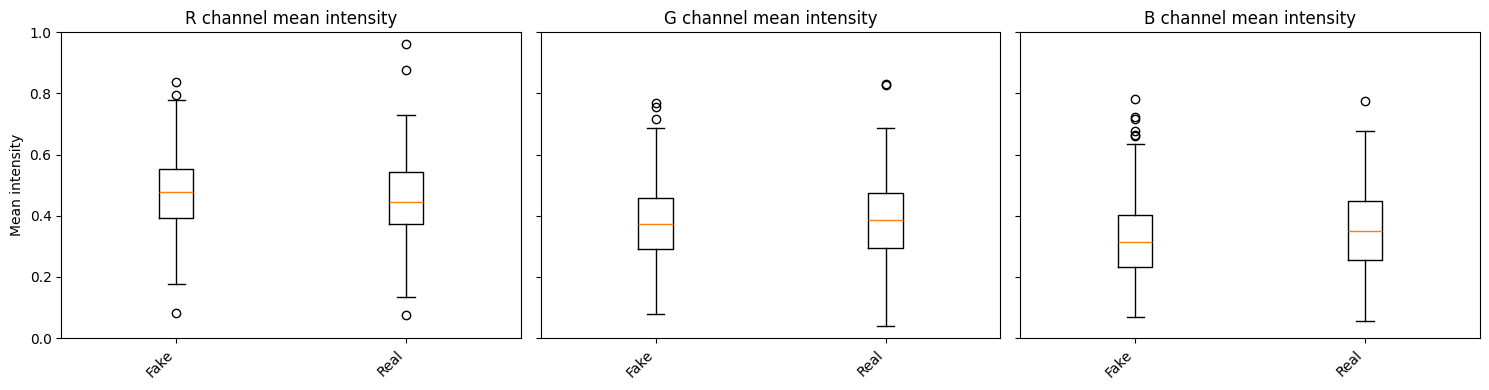

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, channel in zip(axes, ['R', 'G', 'B']):
    channel_df = color_stats[color_stats['channel'] == channel]
    ax.boxplot([channel_df[channel_df['class'] == cls]['mean'] for cls in channel_df['class'].unique()], labels=channel_df['class'].unique(), vert=True)
    ax.set_title(f"{channel} channel mean intensity")
    ax.set_xticklabels(channel_df['class'].unique(), rotation=45, ha='right')
    ax.set_ylim(0, 1)
axes[0].set_ylabel("Mean intensity")
plt.tight_layout()

## Compression & File Size Checks
Review file size variation to identify heavily compressed or anomalous samples.

In [29]:
def attach_file_size(metadata: pd.DataFrame) -> pd.DataFrame:
    metadata = metadata.copy()
    metadata['file_size_kb'] = metadata['path'].apply(lambda p: Path(p).stat().st_size / 1024 if Path(p).exists() else np.nan)
    return metadata
train_metadata = attach_file_size(train_metadata)
size_stats = train_metadata.groupby('class')['file_size_kb'].describe(percentiles=[0.1, 0.5, 0.9]).round(2)
size_stats

,count,mean,std,min,10%,50%,90%,max
class,,,,,,,,
Fake,69840.0,9.13,2.20,1.90,6.46,9.02,11.89,24.75
Real,70001.0,8.92,2.13,2.07,6.36,8.79,11.65,23.68


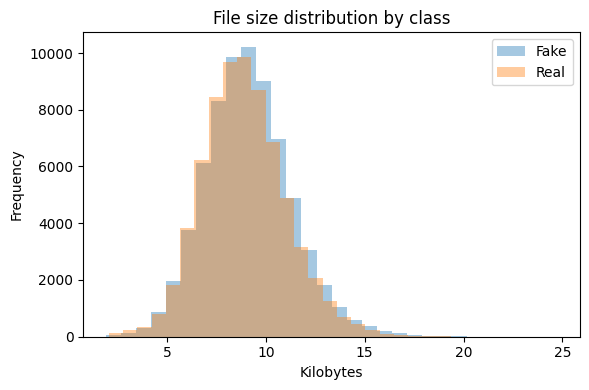

In [30]:
plt.figure(figsize=(6,4))
for cls in sorted(train_metadata['class'].unique()):
    cls_sizes = train_metadata[train_metadata['class'] == cls]['file_size_kb'].dropna()
    plt.hist(cls_sizes, bins=30, alpha=0.4, label=cls)
plt.title('File size distribution by class')
plt.xlabel('Kilobytes')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()

## Key Findings
- Resolution stats highlight min/median/max per class, useful for choosing resize target and catching tiny outliers.\n- Channel intensity boxplots surface color bias or illumination differences between classes.\n- File size summary flags compression range; inspect long tails for mislabeled or corrupted files.
## Next Steps
- Extend metadata extraction to validation/test splits to confirm distributional alignment.\n- Compute blur/sharpness metrics (e.g., Laplacian variance) to identify low-quality frames.\n- Persist metadata to CSV for reproducible preprocessing and data leakage checks.

## Cross-split Metadata Export
Aggregate metadata for Train, Validation, and Test splits, then persist CSV snapshots for reproducibility.

In [31]:
metadata_by_split = {}
for split, split_path in split_paths.items():
    meta = gather_image_metadata(split_path)
    meta = attach_file_size(meta)
    metadata_by_split[split] = meta
reports_dir = Path("../data/metadata_reports")
reports_dir.mkdir(parents=True, exist_ok=True)
for split, df in metadata_by_split.items():
    output_path = reports_dir / f"{split.lower()}_metadata.csv"
    df.to_csv(output_path, index=False)
{split: len(df) for split, df in metadata_by_split.items()}

{'Train': 139841, 'Validation': 39428, 'Test': 10905}

### Split Alignment Diagnostics
Compare resolution and file size distributions across splits to confirm alignment.

In [32]:
resolution_alignment = []
size_alignment = []
for split, df in metadata_by_split.items():
    if df.empty:
        continue
    res_stats = df[['width', 'height']].describe(percentiles=[0.05, 0.5, 0.95]).round(1)
    res_stats['metric'] = res_stats.index
    res_stats['split'] = split
    resolution_alignment.append(res_stats)
    size_stats = df[['file_size_kb']].describe(percentiles=[0.05, 0.5, 0.95]).round(2)
    size_stats['metric'] = size_stats.index
    size_stats['split'] = split
    size_alignment.append(size_stats)
resolution_alignment_df = pd.concat(resolution_alignment, axis=0).set_index(['split', 'metric'])
size_alignment_df = pd.concat(size_alignment, axis=0).set_index(['split', 'metric'])
resolution_alignment_df

width    height
split      metric                    
Train      count   139841.0  139841.0
           mean       256.0     256.0
           std          0.0       0.0
           min        256.0     256.0
           5%         256.0     256.0
           50%        256.0     256.0
           95%        256.0     256.0
           max        256.0     256.0
Validation count    39428.0   39428.0
           mean       256.0     256.0
           std          0.0       0.0
           min        256.0     256.0
           5%         256.0     256.0
           50%        256.0     256.0
           95%        256.0     256.0
           max        256.0     256.0
Test       count    10905.0   10905.0
           mean       256.0     256.0
           std          0.0       0.0
           min        256.0     256.0
           5%         256.0     256.0
           50%        256.0     256.0
           95%        256.0     256.0
           max        256.0     256.0

In [33]:
size_alignment_df

file_size_kb
split      metric              
Train      count      139841.00
           mean            9.02
           std             2.17
           min             1.90
           5%              5.74
           50%             8.91
           95%            12.75
           max            24.75
Validation count       39428.00
           mean            9.74
           std             2.56
           min             1.97
           5%              6.00
           50%             9.56
           95%            14.16
           max            32.66
Test       count       10905.00
           mean           10.40
           std             3.45
           min             2.06
           5%              5.69
           50%             9.88
           95%            16.54
           max            32.52

### Outlier Flagging
Identify images with extreme resolution or file size to review manually.

In [34]:
def flag_outliers(df: pd.DataFrame, split: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    metrics = {}
    for column in ['width', 'height', 'file_size_kb']:
        series = df[column].dropna()
        q1, q3 = series.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        metrics[column] = (lower, upper)
    
    # Initialize mask as a Series of False with the same index as df
    mask = pd.Series(False, index=df.index)
    for column, (lower, upper) in metrics.items():
        mask = mask | (df[column] < lower) | (df[column] > upper)
    
    outliers = df.loc[mask, ['class', 'path', 'width', 'height', 'file_size_kb']].copy()
    outliers['split'] = split
    for column, (lower, upper) in metrics.items():
        outliers[f'{column}_lower'] = lower
        outliers[f'{column}_upper'] = upper
    return outliers
outlier_frames = [flag_outliers(df, split) for split, df in metadata_by_split.items()]
outliers_df = pd.concat([df for df in outlier_frames if not df.empty], ignore_index=True) if any(not df.empty for df in outlier_frames) else pd.DataFrame()
outliers_df.head()

,class,path,width,height,file_size_kb,split,width_lower,width_upper,height_lower,height_upper,file_size_kb_lower,file_size_kb_upper
0,Fake,../data/Dataset/Train/Fake/fake_67439.jpg,256,256,14.924805,Train,256.0,256.0,256.0,256.0,3.391113,14.504395
1,Fake,../data/Dataset/Train/Fake/fake_65904.jpg,256,256,14.969727,Train,256.0,256.0,256.0,256.0,3.391113,14.504395
2,Fake,../data/Dataset/Train/Fake/fake_53739.jpg,256,256,15.069336,Train,256.0,256.0,256.0,256.0,3.391113,14.504395
3,Fake,../data/Dataset/Train/Fake/fake_64066.jpg,256,256,15.642578,Train,256.0,256.0,256.0,256.0,3.391113,14.504395
4,Fake,../data/Dataset/Train/Fake/fake_68069.jpg,256,256,14.542969,Train,256.0,256.0,256.0,256.0,3.391113,14.504395


In [35]:
if not outliers_df.empty:
    outliers_path = reports_dir / "outliers.csv"
    outliers_df.to_csv(outliers_path, index=False)
    print(f"Exported {len(outliers_df)} outliers to {outliers_path}")
outliers_df.groupby(['split', 'class']).size().rename('count') if not outliers_df.empty else "No outliers detected with current thresholds."

Exported 3680 outliers to ../data/metadata_reports/outliers.csv


split       class
Test        Fake       86
            Real      160
Train       Fake     1294
            Real     1103
Validation  Fake      855
            Real      182
Name: count, dtype: int64

EDA Dataset2
